In [1]:
import numpy as np
import torch
import gpytorch
from matplotlib import pyplot as plt
from gpytorch.models import ApproximateGP
from gpytorch.variational import CholeskyVariationalDistribution, IndependentMultitaskVariationalStrategy
from gpytorch.variational import VariationalStrategy

from utils import load_from_HDF, split_data, seed_worker
from dataset import TranSiGenDataset
from tqdm import tqdm

In [2]:
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
data_path = '../data/LINCS2020/processed_data_id.h5'
data = load_from_HDF(data_path)

In [82]:
cell_count = len(set(data['cid']))
feat_type = 'KPGT'
batch_size = 64
learning_rate = 1e-3
beta = 0.1
dropout = 0.1
weight_decay = 1e-5
n_folds = 5
random_seed = 364039
split_type = 'smiles_split'
features_dim = 2304
features_embed_dim = [400]
n_latent = 100
# init_mode = 'pretrain_shRNA'
init_mode = 'random'
n_epochs = 300
molecule_path = '../data/LINCS2020/idx2smi.pickle'
input_dim = 978 + 2304 # Number of input dimensions
output_dim = 978  # Number of input dimensions

In [5]:
pair, pairv, pairt = split_data(data, n_folds=n_folds, split_type=split_type, rnds=random_seed)

In [37]:
train = TranSiGenDataset(
    LINCS_index=pair['LINCS_index'],
    mol_feature_type=feat_type,
    mol_id=pair['canonical_smiles'],
    cid=pair['cid']
)

valid = TranSiGenDataset(
    LINCS_index=pairv['LINCS_index'],
    mol_feature_type=feat_type,
    mol_id=pairv['canonical_smiles'],
    cid=pairv['cid']
)

test = TranSiGenDataset(
    LINCS_index=pairt['LINCS_index'],
    mol_feature_type=feat_type,
    mol_id=pairt['canonical_smiles'],
    cid=pairt['cid']
)

train_loader = torch.utils.data.DataLoader(dataset=train, batch_size=batch_size, shuffle=True, drop_last=False, num_workers=4, worker_init_fn=seed_worker)
valid_loader = torch.utils.data.DataLoader(dataset=valid, batch_size=batch_size, shuffle=True, drop_last=False, num_workers=4, worker_init_fn=seed_worker)
test_loader = torch.utils.data.DataLoader(dataset=test, batch_size=batch_size, shuffle=True, drop_last=False, num_workers=4, worker_init_fn=seed_worker)

In [95]:
num_latents = 100
num_tasks = output_dim

class MultitaskGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, num_latents, num_tasks, input_dim):
        # Inducing points now have input_dim dimensions
        inducing_points = torch.rand(num_latents, 16, input_dim)

        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(-2),
            batch_shape=torch.Size([num_latents])
        )

        variational_strategy = gpytorch.variational.LMCVariationalStrategy(
            gpytorch.variational.VariationalStrategy(
                self,
                inducing_points,
                variational_distribution,
                learn_inducing_locations=True
            ),
            num_tasks=num_tasks,
            num_latents=num_latents,
            latent_dim=-1  # This should point to the latent dimension
        )

        super().__init__(variational_strategy)

        # Mean and covariance modules remain similar but handle multi-input
        self.mean_module = gpytorch.means.ConstantMean(batch_shape=torch.Size([num_latents]))
        self.covar_module = gpytorch.kernels.ScaleKernel(
            # RBFKernel will automatically handle multi-dimensional inputs
            gpytorch.kernels.RBFKernel(ard_num_dims=input_dim, batch_shape=torch.Size([num_latents])),
            batch_shape=torch.Size([num_latents])
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

model = MultitaskGPModel(num_latents, num_tasks, input_dim)
likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=num_tasks)

In [96]:
model.train()
likelihood.train()

optimizer = torch.optim.Adam([
    {'params': model.parameters()},
    {'params': likelihood.parameters()},
], lr=0.1)

# Our loss object. We're using the VariationalELBO
mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=len(train))

In [85]:
losses = []

In [87]:
epochs_iter = tqdm(range(50), desc="Epoch")
for i in epochs_iter:
    batch_loss = 0
    for x_batch, y_batch, mol_features, *_ in train_loader:
        optimizer.zero_grad()
        _input = torch.concat([x_batch, mol_features], dim=-1)
        output = model(_input)
        loss = -mll(output, y_batch)
        batch_loss += loss.item()
        loss.backward()
        optimizer.step()
    losses.append(batch_loss / len(train_loader))

Epoch:  14%|█▍        | 7/50 [03:19<20:22, 28.44s/it]
Exception ignored in: <function WeakSet.__init__.<locals>._remove at 0x7f137e727d90>
Traceback (most recent call last):
  File "/home/samir/miniconda3/envs/transigen/lib/python3.10/_weakrefset.py", line 39, in _remove
    def _remove(item, selfref=ref(self)):
KeyboardInterrupt: 


KeyboardInterrupt: 

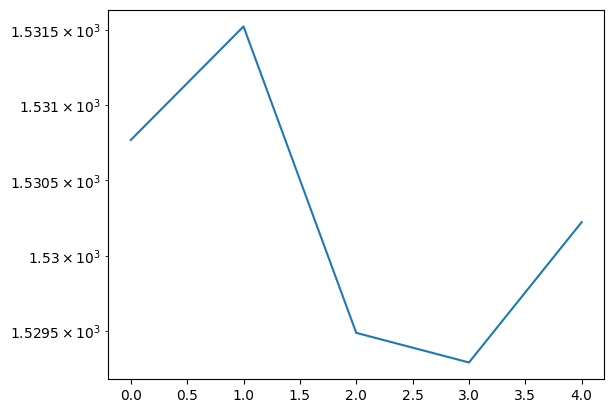

In [90]:
plt.plot(losses[2:])
plt.yscale('log')

In [61]:
losses

[1884.5966550084274,
 1533.9579634232955,
 1532.5392292907798,
 1531.8762531668717,
 1531.7985014999576,
 1531.3131128360328,
 1531.9424253797595,
 1530.5621687372795,
 1532.183607994297,
 1531.4345527555759]

In [92]:
model.eval()
likelihood.eval()

with torch.no_grad():
    test_x, _, test_mol_feat, *_ = next(iter(test_loader))
    observed_pred = likelihood(model(torch.concat([test_x, test_mol_feat], dim=-1)))

In [93]:
observed_pred.mean

tensor([[ 9.8857,  6.5959,  8.2057,  ...,  9.2951, 10.9114,  7.7242],
        [ 9.8857,  6.5959,  8.2057,  ...,  9.2951, 10.9114,  7.7242],
        [ 9.8857,  6.5959,  8.2057,  ...,  9.2951, 10.9114,  7.7242],
        ...,
        [ 9.8857,  6.5959,  8.2057,  ...,  9.2951, 10.9114,  7.7242],
        [ 9.8857,  6.5959,  8.2057,  ...,  9.2951, 10.9114,  7.7242],
        [ 9.8857,  6.5959,  8.2057,  ...,  9.2951, 10.9114,  7.7242]])

In [94]:
((test_x - observed_pred.mean) ** 2).mean()

tensor(1.6777)